## Gradient Boosting classification of the Iris dataset

### Code midified from: Ryan Wang, Prediction with Gradient Boosting Classifier
https://www.kaggle.com/beagle01/prediction-with-gradient-boosting-classifier

In [1]:
import pandas as pd
iris = pd.read_csv("..\input\Iris.csv")

In [2]:
X = iris.drop(['Id','Species'],axis=1)
y = iris['Species']

In [3]:
X.shape, y.shape

((150, 4), (150,))

In [4]:
# transform data to a given range. default=(0, 1)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scale = scaler.fit_transform(X)

In [5]:
# split training feature and target sets into training and validation subsets
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(X_scale, y, random_state=0, test_size=0.2)

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_validation.shape)
print(y_validation.shape)

(120, 4)
(120,)
(30, 4)
(30,)


In [7]:
# import machine learning algorithms
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [8]:
# train with Gradient Boosting algorithm
# compute the accuracy scores on train and validation sets when training with different learning rates

learning_rates = [0.05, 0.1, 0.25, 0.5, 0.75, 1]
for learning_rate in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=20, learning_rate = learning_rate, max_features=2, max_depth = 2, random_state = 0)
    gb.fit(X_train, y_train)
    print("Learning rate: ", learning_rate)
    print("Accuracy score (training): {0:.3f}".format(gb.score(X_train, y_train)))
    print("Accuracy score (validation): {0:.3f}".format(gb.score(X_validation, y_validation)))
    print()

Learning rate:  0.05
Accuracy score (training): 0.967
Accuracy score (validation): 1.000

Learning rate:  0.1
Accuracy score (training): 0.967
Accuracy score (validation): 1.000

Learning rate:  0.25
Accuracy score (training): 1.000
Accuracy score (validation): 1.000

Learning rate:  0.5
Accuracy score (training): 1.000
Accuracy score (validation): 1.000

Learning rate:  0.75
Accuracy score (training): 1.000
Accuracy score (validation): 1.000

Learning rate:  1
Accuracy score (training): 1.000
Accuracy score (validation): 1.000



In [9]:
# Output confusion matrix and classification report of Gradient Boosting algorithm on validation set

gb = GradientBoostingClassifier(n_estimators=20, learning_rate = 0.5, max_features=2, max_depth = 2, random_state = 0)
gb.fit(X_train, y_train)
predictions = gb.predict(X_validation)

print("Confusion Matrix:")
print(confusion_matrix(y_validation, predictions))
print()
print("Classification Report")
print(classification_report(y_validation, predictions))

Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



[0.01414794 0.01662106 0.50661541 0.46261558]


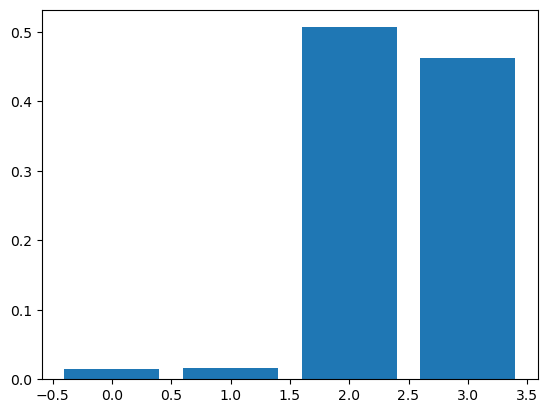

In [10]:
from matplotlib import pyplot
print(gb.feature_importances_)
# plot
pyplot.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
pyplot.show()